In [24]:
"""
Multi-Method Analysis of Household Wealth Dynamics
Research Question: How do different household financial behavior groups 
experience wealth changes over time, and can we predict future wealth 
using time series models?

Methods:
1. K-means Clustering - Identify household financial behavior groups
2. Time Series Analysis - Model temporal patterns with ARIMA
3. Maximum Likelihood Estimation - Baseline prediction model
4. Permutation Tests - Non-parametric hypothesis testing

Lavanyaa Gupta
DAT 402
Due: 11/7/25
"""

'\nMulti-Method Analysis of Household Wealth Dynamics\nResearch Question: How do different household financial behavior groups \nexperience wealth changes over time, and can we predict future wealth \nusing time series models?\n\nMethods:\n1. K-means Clustering - Identify household financial behavior groups\n2. Time Series Analysis - Model temporal patterns with ARIMA\n3. Maximum Likelihood Estimation - Baseline prediction model\n4. Permutation Tests - Non-parametric hypothesis testing\n\nLavanyaa Gupta\nDAT 402\nDue: 11/7/25\n'

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

np.random.seed(42)

In [7]:
# 1. DATA LOADING AND PREPROCESSING
df = pd.read_csv(r"C:\Users\lavan\Downloads\DAT402_Project1_Data.csv")

temporal_cols = [col for col in df.columns if col.startswith('ER47')][:10]  
wealth_cols = [col for col in df.columns if 'Wealth' in col or 'Income' in col]

print(f"\nDataset Shape: {df.shape}")
print(f"Temporal Columns Identified: {len(temporal_cols)}")
print(f"Sample Columns: {temporal_cols[:5]}")

df_clean = df.dropna(thresh=len(temporal_cols)*0.5) 
print(f"Shape after cleaning: {df_clean.shape}")


Dataset Shape: (10210, 36)
Temporal Columns Identified: 9
Sample Columns: ['ER47301', 'ER47302', 'ER47316', 'ER47317', 'ER47318']
Shape after cleaning: (10210, 36)


       ER47301      ER47302      ER47316      ER47317      ER47318  \
count   8907.0  8904.000000  8907.000000  8907.000000  8907.000000   
mean       6.0  4467.870283     2.597283    45.213989     1.320534   
std        0.0  2580.211365     1.471431    16.604831     0.466708   
min        6.0     1.000000     1.000000    17.000000     1.000000   
25%        6.0  2234.750000     1.000000    31.000000     1.000000   
50%        6.0  4466.500000     2.000000    43.000000     1.000000   
75%        6.0  6702.250000     4.000000    57.000000     2.000000   
max        6.0  8941.000000    14.000000    98.000000     2.000000   

           ER47323      ER47329      ER47448      ER47456  
count  8903.000000  8907.000000  8901.000000  8827.000000  
mean      2.031001     3.059167     2.059881    32.368189  
std       1.230439     2.286955     1.665144    20.902630  
min       1.000000     1.000000     1.000000     0.000000  
25%       1.000000     1.000000     1.000000    12.000000  
50%      

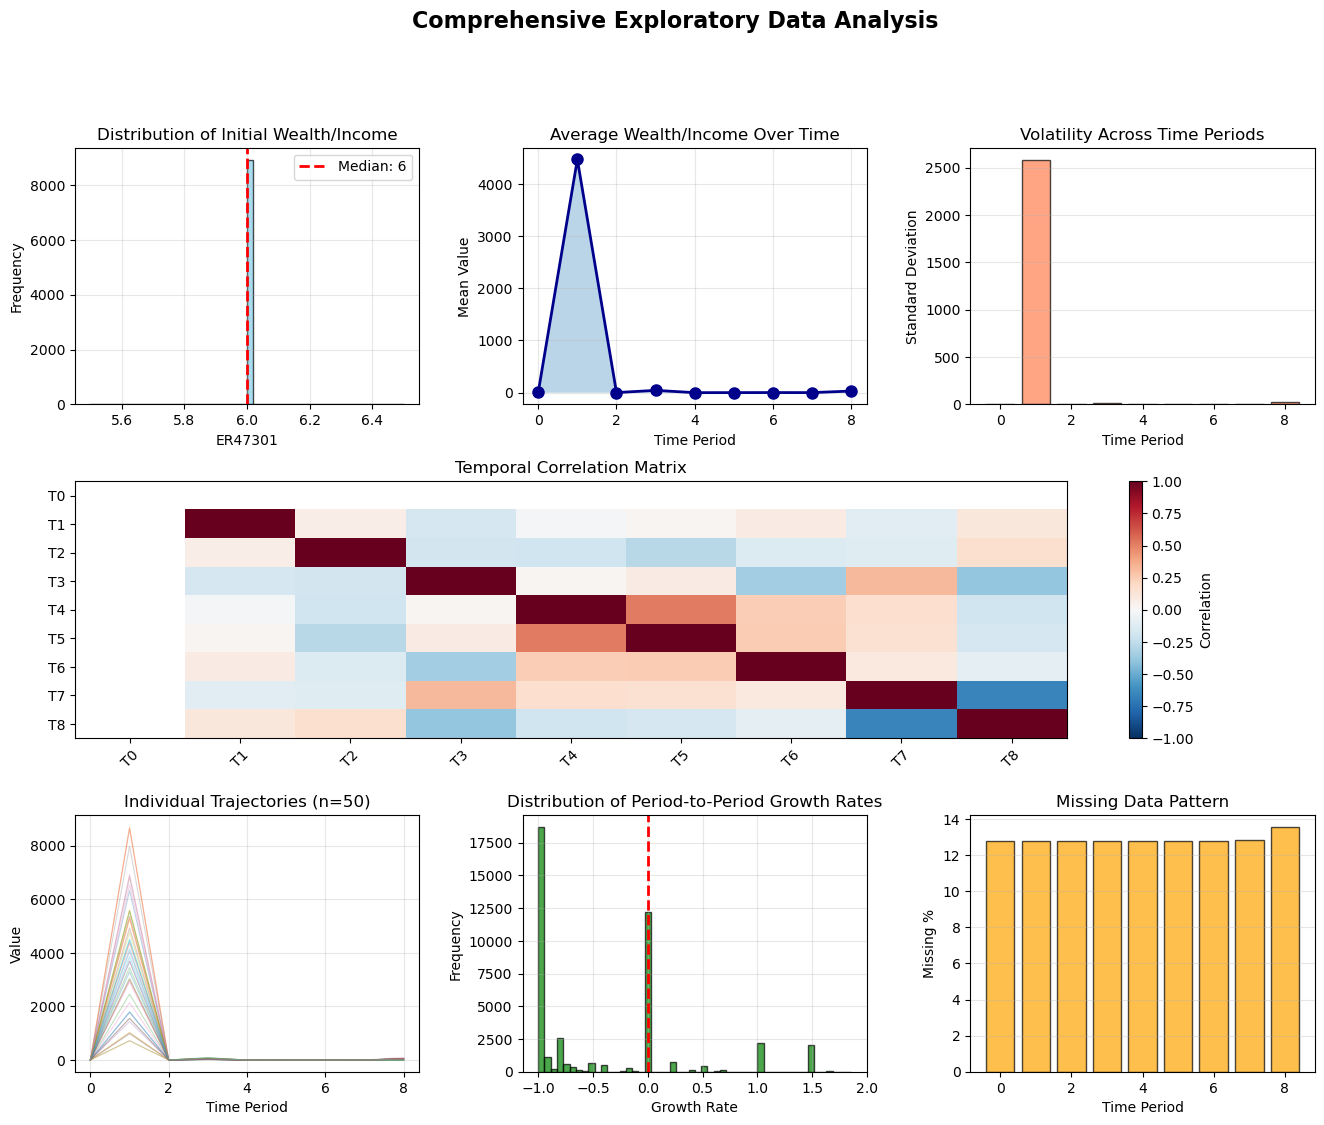

In [8]:
# 2. EXPLORATORY DATA ANALYSIS
print(df_clean[temporal_cols].describe())

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
data_plot = df_clean[temporal_cols[0]].dropna()
ax1.hist(data_plot, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
ax1.axvline(data_plot.median(), color='red', linestyle='--', linewidth=2, label=f'Median: {data_plot.median():.0f}')
ax1.set_xlabel(temporal_cols[0])
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Initial Wealth/Income')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
means = df_clean[temporal_cols].mean()
ax2.plot(range(len(means)), means, marker='o', linewidth=2, markersize=8, color='darkblue')
ax2.fill_between(range(len(means)), means, alpha=0.3)
ax2.set_xlabel('Time Period')
ax2.set_ylabel('Mean Value')
ax2.set_title('Average Wealth/Income Over Time')
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
stds = df_clean[temporal_cols].std()
ax3.bar(range(len(stds)), stds, color='coral', edgecolor='black', alpha=0.7)
ax3.set_xlabel('Time Period')
ax3.set_ylabel('Standard Deviation')
ax3.set_title('Volatility Across Time Periods')
ax3.grid(True, alpha=0.3, axis='y')

ax4 = fig.add_subplot(gs[1, :])
corr_matrix = df_clean[temporal_cols].corr()
im = ax4.imshow(corr_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
ax4.set_xticks(range(len(temporal_cols)))
ax4.set_yticks(range(len(temporal_cols)))
ax4.set_xticklabels([f'T{i}' for i in range(len(temporal_cols))], rotation=45)
ax4.set_yticklabels([f'T{i}' for i in range(len(temporal_cols))])
ax4.set_title('Temporal Correlation Matrix')
plt.colorbar(im, ax=ax4, label='Correlation')

ax5 = fig.add_subplot(gs[2, 0])
sample_size = min(50, len(df_clean))
for idx in np.random.choice(df_clean.index, sample_size, replace=False):
    trajectory = df_clean.loc[idx, temporal_cols].values
    if not np.all(np.isnan(trajectory)):
        ax5.plot(trajectory, alpha=0.3, linewidth=0.8)
ax5.set_xlabel('Time Period')
ax5.set_ylabel('Value')
ax5.set_title(f'Individual Trajectories (n={sample_size})')
ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(gs[2, 1])
growth_rates = []
for i in range(len(temporal_cols)-1):
    col1, col2 = temporal_cols[i], temporal_cols[i+1]
    rates = ((df_clean[col2] - df_clean[col1]) / df_clean[col1].abs()).replace([np.inf, -np.inf], np.nan).dropna()
    growth_rates.extend(rates)
growth_rates = np.array(growth_rates)
growth_rates = growth_rates[(growth_rates > -2) & (growth_rates < 2)]  # Remove extreme outliers
ax6.hist(growth_rates, bins=50, edgecolor='black', alpha=0.7, color='green')
ax6.axvline(0, color='red', linestyle='--', linewidth=2)
ax6.set_xlabel('Growth Rate')
ax6.set_ylabel('Frequency')
ax6.set_title('Distribution of Period-to-Period Growth Rates')
ax6.grid(True, alpha=0.3)

ax7 = fig.add_subplot(gs[2, 2])
missing_pct = df_clean[temporal_cols].isnull().sum() / len(df_clean) * 100
ax7.bar(range(len(missing_pct)), missing_pct, color='orange', edgecolor='black', alpha=0.7)
ax7.set_xlabel('Time Period')
ax7.set_ylabel('Missing %')
ax7.set_title('Missing Data Pattern')
ax7.grid(True, alpha=0.3, axis='y')

plt.suptitle('Comprehensive Exploratory Data Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('eda_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


Sample size for clustering: 8815

Testing different numbers of clusters...
  k=2: Inertia=55451.88, Silhouette=0.258
  k=3: Inertia=45981.78, Silhouette=0.221
  k=4: Inertia=41757.60, Silhouette=0.205
  k=5: Inertia=38347.65, Silhouette=0.217
  k=6: Inertia=35748.41, Silhouette=0.220
  k=7: Inertia=33349.85, Silhouette=0.197
  k=8: Inertia=31283.32, Silhouette=0.200


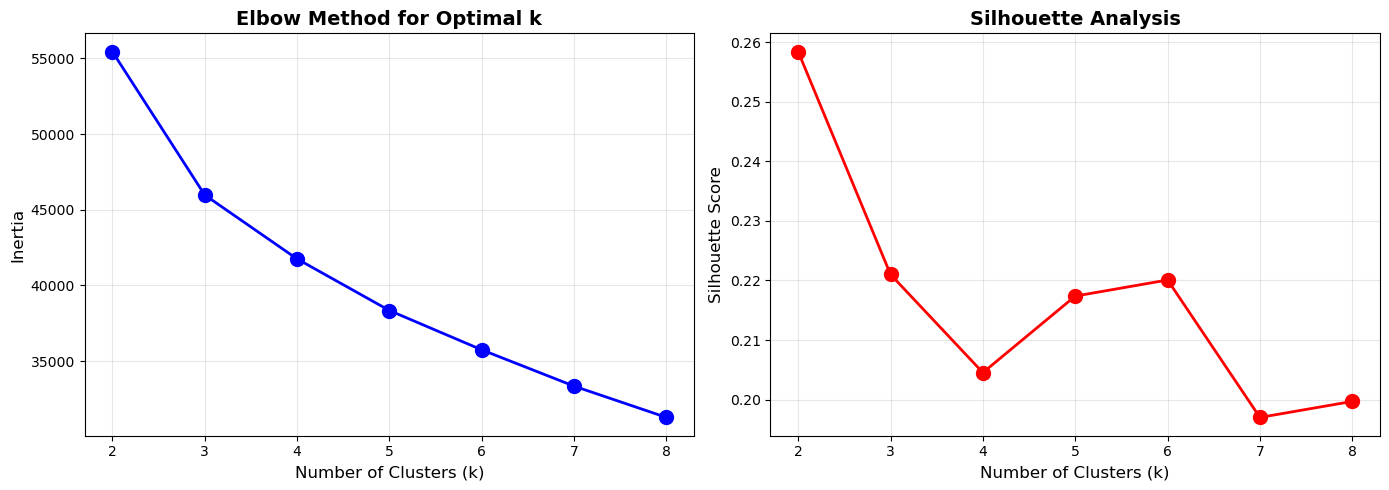


✓ Optimal number of clusters: 2


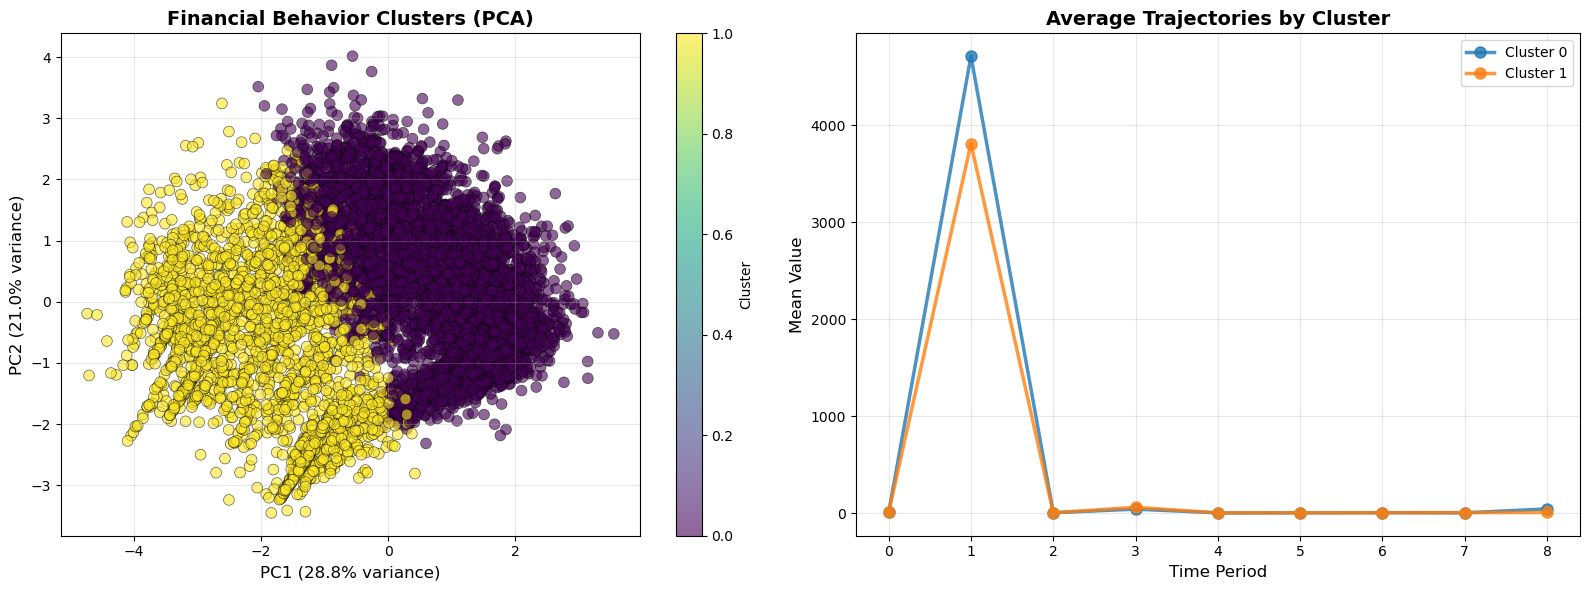


Cluster Characteristics:

Cluster 0 (n=6399):
  Mean Value: 534.90
  Std Dev: 289.84
  Median Value: 542.22
  Growth Trend: 36.50

Cluster 1 (n=2416):
  Mean Value: 432.96
  Std Dev: 278.89
  Median Value: 407.61
  Growth Trend: -0.39


In [9]:
# 3. K-MEANS CLUSTERING - IDENTIFY FINANCIAL BEHAVIOR GROUPS
cluster_data = df_clean[temporal_cols].dropna()
print(f"\nSample size for clustering: {len(cluster_data)}")

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

inertias = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    kmeans.fit(scaled_data)
    inertias.append(kmeans.inertia_)
    
    from sklearn.metrics import silhouette_score
    sil_score = silhouette_score(scaled_data, kmeans.labels_)
    silhouette_scores.append(sil_score)
    print(f"  k={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={sil_score:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=10)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=10)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_selection.png', dpi=300, bbox_inches='tight')
plt.show()

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\n Optimal number of clusters: {optimal_k}")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=20, max_iter=300)
cluster_labels = kmeans_final.fit_predict(scaled_data)

cluster_data_labeled = cluster_data.copy()
cluster_data_labeled['Cluster'] = cluster_labels

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter = axes[0].scatter(pca_features[:, 0], pca_features[:, 1], 
                         c=cluster_labels, cmap='viridis', 
                         s=60, alpha=0.6, edgecolors='black', linewidths=0.5)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
axes[0].set_title('Financial Behavior Clusters (PCA)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[0], label='Cluster')

for i in range(optimal_k):
    cluster_mean = cluster_data_labeled[cluster_data_labeled['Cluster'] == i][temporal_cols].mean()
    axes[1].plot(range(len(temporal_cols)), cluster_mean, 
                marker='o', linewidth=2.5, markersize=8, label=f'Cluster {i}', alpha=0.8)
axes[1].set_xlabel('Time Period', fontsize=12)
axes[1].set_ylabel('Mean Value', fontsize=12)
axes[1].set_title('Average Trajectories by Cluster', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

for i in range(optimal_k):
    cluster_subset = cluster_data_labeled[cluster_data_labeled['Cluster'] == i][temporal_cols]
    print(f"\nCluster {i} (n={len(cluster_subset)}):")
    print(f"  Mean Value: {cluster_subset.mean().mean():.2f}")
    print(f"  Std Dev: {cluster_subset.std().mean():.2f}")
    print(f"  Median Value: {cluster_subset.median().mean():.2f}")
    print(f"  Growth Trend: {(cluster_subset.iloc[:, -1].mean() - cluster_subset.iloc[:, 0].mean()):.2f}")


Time series length: 9
Time series statistics:
count       9.000000
mean      506.957219
std      1485.455467
min         1.321724
25%         2.060465
50%         3.055133
75%        32.388996
max      4467.943392
dtype: float64
  ADF Statistic: -194.4477
  p-value: 0.0000
  Critical Values:
    1%: -4.939
    5%: -3.478
    10%: -2.844
Series is stationary (reject H0 of unit root)


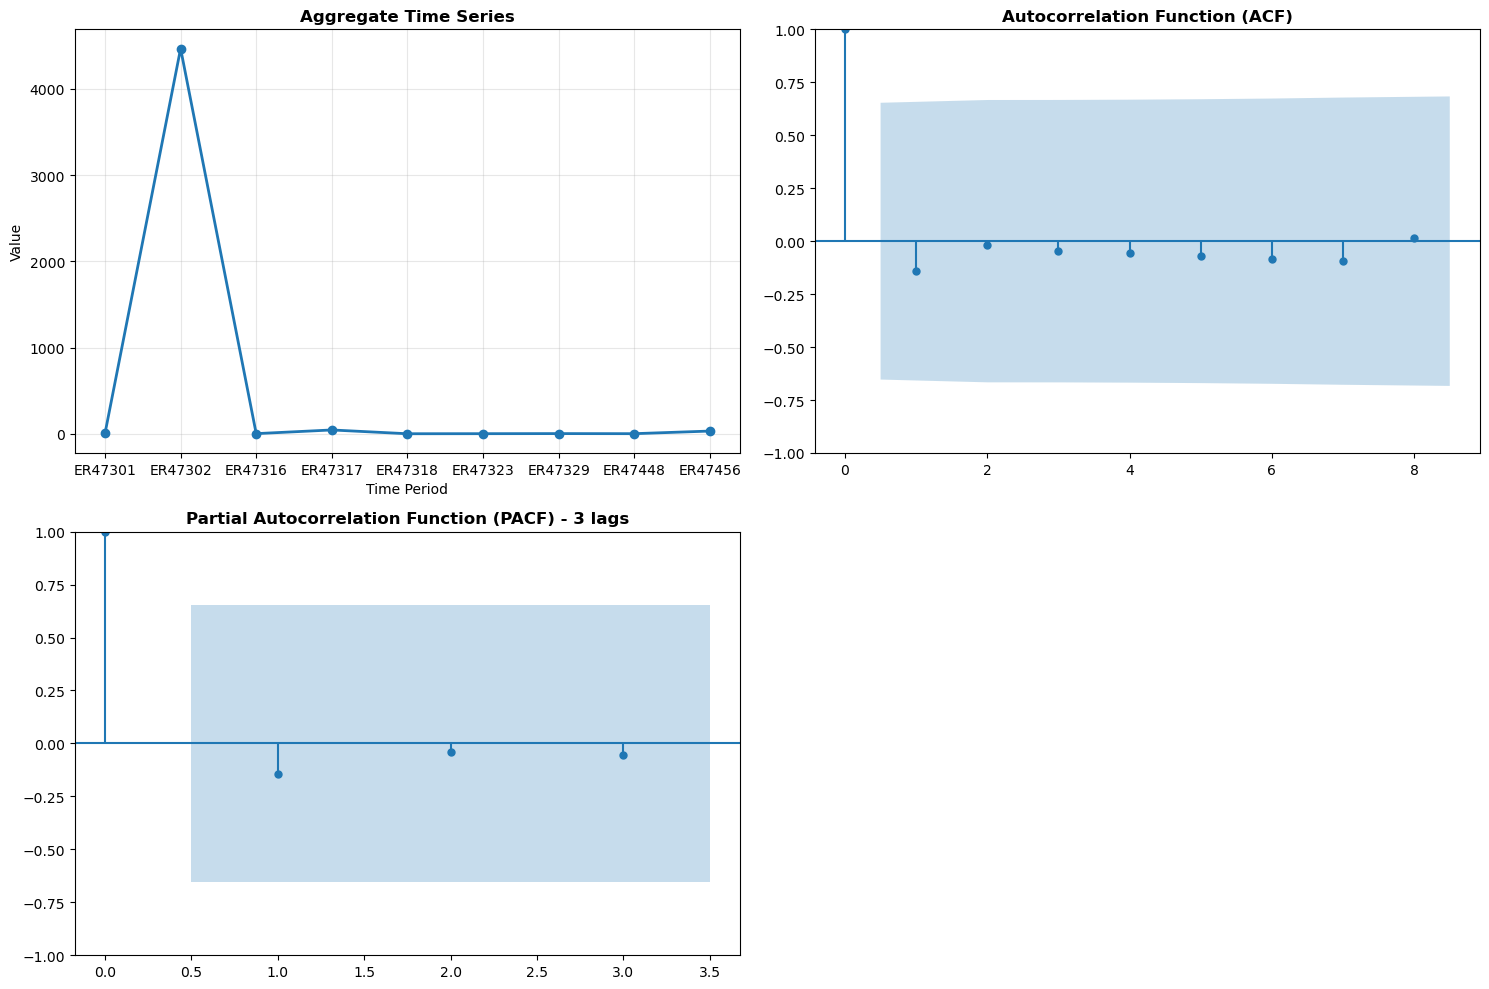


Fitting ARIMA models...
ARIMA(1, 0, 0): AIC=161.77, BIC=162.36


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq

ARIMA(0, 0, 1): AIC=169.68, BIC=170.27


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq

ARIMA(1, 0, 1): AIC=163.94, BIC=164.73


...

ARIMA(2, 0, 0): AIC=163.75, BIC=164.54
ARIMA(0, 0, 2): AIC=164.69, BIC=165.48


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq

ARIMA(2, 0, 1): Failed to converge


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq

ARIMA(1, 0, 2): AIC=1601.92, BIC=1602.90

 Best model: ARIMA(1, 0, 0) with AIC=161.77
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                    9
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 -77.886
Date:                Fri, 07 Nov 2025   AIC                            161.773
Time:                        18:31:13   BIC                            162.364
Sample:                             0   HQIC                           160.496
                                  - 9                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        515.1626   3.13e+04      0.016      0.987   -6.08e+04    6.19e+04
ar.L1         -0.1318     78.278     -0.002  

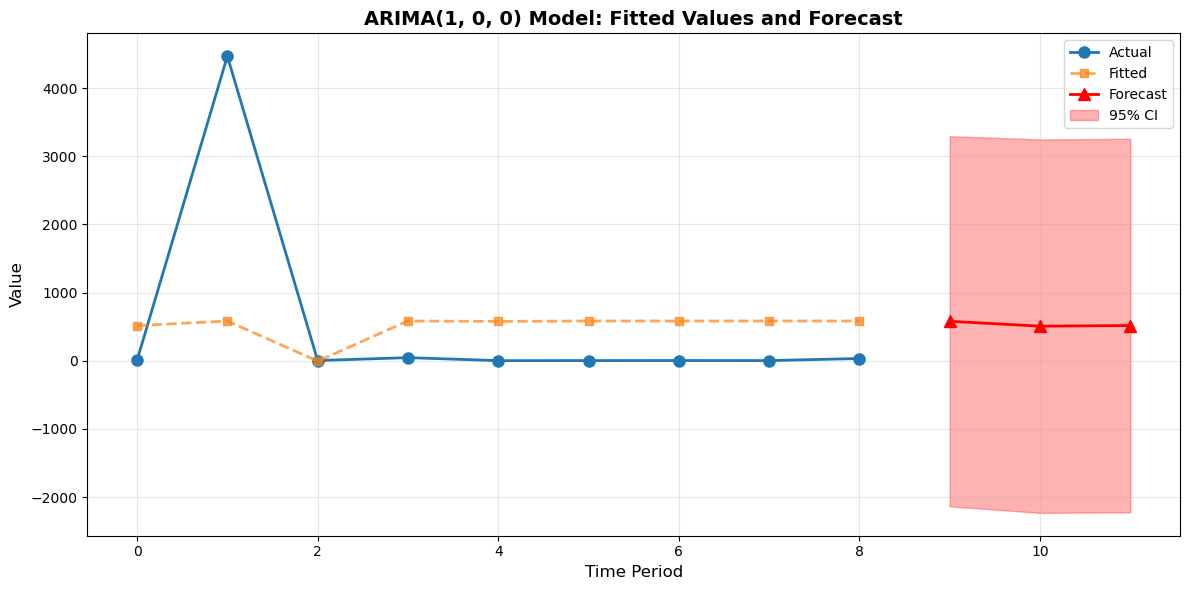

  MSE: 1921302.87
  RMSE: 1386.11
  R²: 0.0204


In [22]:
# 4. TIME SERIES ANALYSIS - ARIMA MODELING
ts_data = cluster_data_labeled[temporal_cols].mean()
print(f"\nTime series length: {len(ts_data)}")
print(f"Time series statistics:")
print(ts_data.describe())

adf_result = adfuller(ts_data.dropna())
print(f"  ADF Statistic: {adf_result[0]:.4f}")
print(f"  p-value: {adf_result[1]:.4f}")
print(f"  Critical Values:")
for key, value in adf_result[4].items():
    print(f"    {key}: {value:.3f}")

if adf_result[1] < 0.05:
    print("Series is stationary (reject H0 of unit root)")
    d_order = 0
else:
    print("Series is non-stationary (fail to reject H0)")
    d_order = 1

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(ts_data, marker='o', linewidth=2, markersize=6)
axes[0, 0].set_xlabel('Time Period')
axes[0, 0].set_ylabel('Value')
axes[0, 0].set_title('Aggregate Time Series', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

plot_acf(ts_data.dropna(), lags=min(len(ts_data)-1, 10), ax=axes[0, 1])
axes[0, 1].set_title('Autocorrelation Function (ACF)', fontweight='bold')

max_lags = max(1, min(len(ts_data) // 2 - 1, 10))
plot_pacf(ts_data.dropna(), lags=max_lags, ax=axes[1, 0])
axes[1, 0].set_title(f'Partial Autocorrelation Function (PACF) - {max_lags} lags', fontweight='bold')

if d_order == 1:
    ts_diff = ts_data.diff().dropna()
    axes[1, 1].plot(ts_diff, marker='o', linewidth=2, markersize=6, color='orange')
    axes[1, 1].set_xlabel('Time Period')
    axes[1, 1].set_ylabel('Differenced Value')
    axes[1, 1].set_title('First Difference of Series', fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
else:
    axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('time_series_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFitting ARIMA models...")
best_aic = np.inf
best_order = None
best_model = None

orders_to_try = [
    (1, d_order, 0),  
    (0, d_order, 1), 
    (1, d_order, 1),  
    (2, d_order, 0), 
    (0, d_order, 2),  
    (2, d_order, 1),  
    (1, d_order, 2),  
]

for order in orders_to_try:
    try:
        model = ARIMA(ts_data, order=order)
        fitted_model = model.fit()
        print(f"ARIMA{order}: AIC={fitted_model.aic:.2f}, BIC={fitted_model.bic:.2f}")
        
        if fitted_model.aic < best_aic:
            best_aic = fitted_model.aic
            best_order = order
            best_model = fitted_model
    except:
        print(f"ARIMA{order}: Failed to converge")

print(f"\n Best model: ARIMA{best_order} with AIC={best_aic:.2f}")
print(best_model.summary())

forecast_steps = 3
forecast = best_model.forecast(steps=forecast_steps)
forecast_ci = best_model.get_forecast(steps=forecast_steps).conf_int()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(range(len(ts_data)), ts_data, 'o-', label='Actual', linewidth=2, markersize=8)
ax.plot(range(len(ts_data)), best_model.fittedvalues, 's--', 
        label='Fitted', linewidth=2, markersize=6, alpha=0.7)
forecast_index = range(len(ts_data), len(ts_data) + forecast_steps)
ax.plot(forecast_index, forecast, 'r^-', label='Forecast', linewidth=2, markersize=8)
ax.fill_between(forecast_index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], 
                alpha=0.3, color='red', label='95% CI')
ax.set_xlabel('Time Period', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title(f'ARIMA{best_order} Model: Fitted Values and Forecast', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('arima_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

fitted_values = best_model.fittedvalues
actual_values = ts_data[fitted_values.index]
mse = mean_squared_error(actual_values, fitted_values)
r2 = r2_score(actual_values, fitted_values)
print(f"  MSE: {mse:.2f}")
print(f"  RMSE: {np.sqrt(mse):.2f}")
print(f"  R²: {r2:.4f}")


Sample size for MLE: 8815

Optimizing MLE parameters...

MLE Results:
  Intercept (β₀): 49.50
  Slope (β₁): -8.3045
  Sigma (σ): 15.66
  Negative Log-Likelihood: 36758.63
  Optimization Success: True

  MSE: 245.22
  RMSE: 15.66
  R²: 0.4379

Inference:
  β₀: SE=0.27, t=186.49, p=0.0000
  β₁: SE=0.1002, t=-82.87, p=0.0000


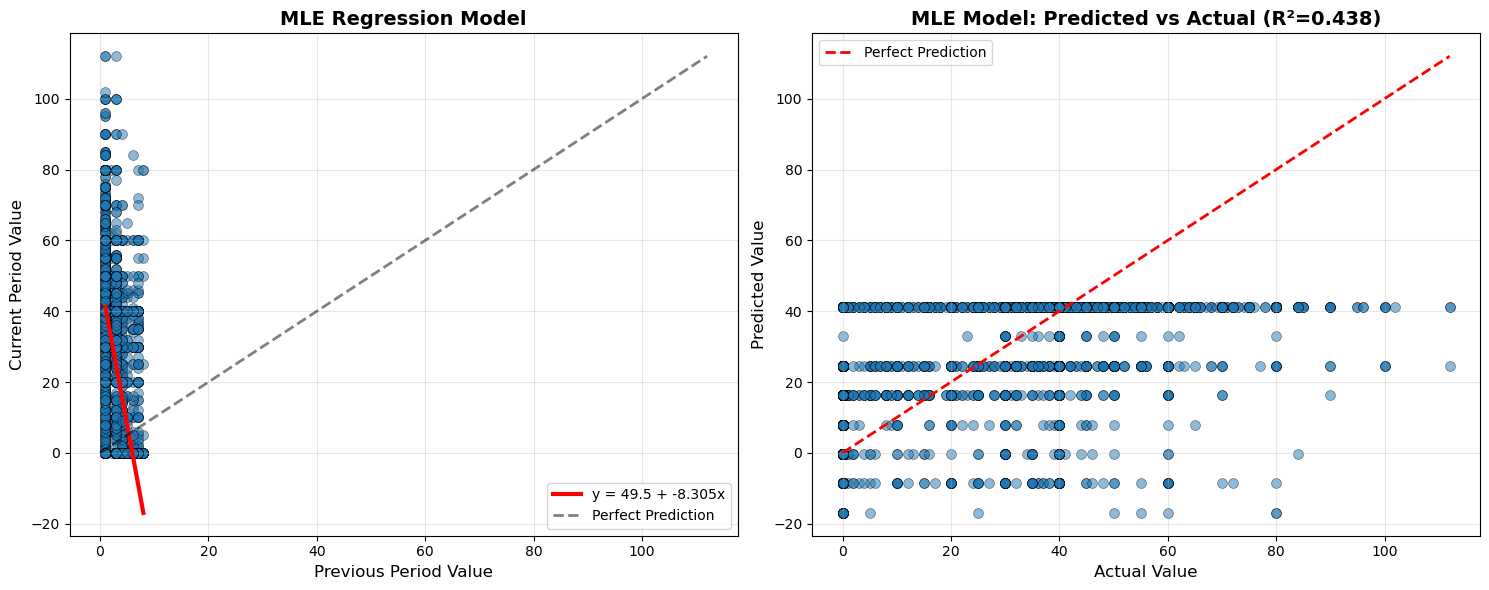

In [14]:
# 5. MAXIMUM LIKELIHOOD ESTIMATION - BASELINE REGRESSION

X_mle = cluster_data_labeled[temporal_cols[:-1]].values
y_mle = cluster_data_labeled[temporal_cols[-1]].values
X_mle_simple = X_mle[:, -1].reshape(-1, 1)

mask = ~np.isnan(X_mle_simple).flatten() & ~np.isnan(y_mle)
X_mle_clean = X_mle_simple[mask]
y_mle_clean = y_mle[mask]

print(f"\nSample size for MLE: {len(y_mle_clean)}")

X_mle_int = np.column_stack([np.ones(len(X_mle_clean)), X_mle_clean])

def neg_log_likelihood(params, X, y):
    beta = params[:-1]
    sigma = params[-1]
    
    if sigma <= 0:
        return 1e10  
    
    y_pred = X @ beta
    residuals = y - y_pred
    n = len(y)
    
    nll = n/2 * np.log(2*np.pi*sigma**2) + np.sum(residuals**2)/(2*sigma**2)
    return nll

init_params = np.zeros(X_mle_int.shape[1] + 1)
init_params[-1] = np.std(y_mle_clean)  # Initial sigma guess

from scipy.optimize import minimize
result = minimize(neg_log_likelihood, init_params, args=(X_mle_int, y_mle_clean),
                 method='L-BFGS-B', 
                 bounds=[(None, None)] * (len(init_params)-1) + [(0.01, None)])

beta_mle = result.x[:-1]
sigma_mle = result.x[-1]

print(f"  Intercept (β₀): {beta_mle[0]:.2f}")
print(f"  Slope (β₁): {beta_mle[1]:.4f}")
print(f"  Sigma (σ): {sigma_mle:.2f}")
print(f"  Negative Log-Likelihood: {result.fun:.2f}")
print(f"  Optimization Success: {result.success}")

y_pred_mle = X_mle_int @ beta_mle

mse_mle = mean_squared_error(y_mle_clean, y_pred_mle)
r2_mle = r2_score(y_mle_clean, y_pred_mle)
print(f"\n  MSE: {mse_mle:.2f}")
print(f"  RMSE: {np.sqrt(mse_mle):.2f}")
print(f"  R²: {r2_mle:.4f}")

residuals = y_mle_clean - y_pred_mle
X_centered = X_mle_clean - X_mle_clean.mean()
se_beta1 = sigma_mle / np.sqrt(np.sum(X_centered**2))
se_beta0 = sigma_mle * np.sqrt(1/len(y_mle_clean) + X_mle_clean.mean()**2/np.sum(X_centered**2))

t_stat_beta0 = beta_mle[0] / se_beta0
t_stat_beta1 = beta_mle[1] / se_beta1
df = len(y_mle_clean) - 2

p_value_beta0 = 2 * (1 - stats.t.cdf(abs(t_stat_beta0), df))
p_value_beta1 = 2 * (1 - stats.t.cdf(abs(t_stat_beta1), df))

print(f"\nInference:")
print(f"  β₀: SE={se_beta0:.2f}, t={t_stat_beta0:.2f}, p={p_value_beta0:.4f}")
print(f"  β₁: SE={se_beta1:.4f}, t={t_stat_beta1:.2f}, p={p_value_beta1:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(X_mle_clean, y_mle_clean, alpha=0.5, s=50, edgecolors='black', linewidths=0.5)
x_range = np.linspace(X_mle_clean.min(), X_mle_clean.max(), 100)
y_pred_line = beta_mle[0] + beta_mle[1] * x_range
axes[0].plot(x_range, y_pred_line, 'r-', linewidth=3, label=f'y = {beta_mle[0]:.1f} + {beta_mle[1]:.3f}x')
axes[0].plot([y_mle_clean.min(), y_mle_clean.max()], 
             [y_mle_clean.min(), y_mle_clean.max()], 
             'k--', alpha=0.5, linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Previous Period Value', fontsize=12)
axes[0].set_ylabel('Current Period Value', fontsize=12)
axes[0].set_title('MLE Regression Model', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_mle_clean, y_pred_mle, alpha=0.5, s=50, edgecolors='black', linewidths=0.5)
axes[1].plot([y_mle_clean.min(), y_mle_clean.max()], 
             [y_mle_clean.min(), y_mle_clean.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Value', fontsize=12)
axes[1].set_ylabel('Predicted Value', fontsize=12)
axes[1].set_title(f'MLE Model: Predicted vs Actual (R²={r2_mle:.3f})', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mle_regression.png', dpi=300, bbox_inches='tight')
plt.show()


Hypothesis Testing:
H₀: Cluster membership has no effect on wealth trajectory
H₁: Different clusters have significantly different wealth patterns

Observed test statistic (between-cluster variance): 2386080.47
Running 10000 permutations...
  Progress: 0/10000
  Progress: 2000/10000
  Progress: 4000/10000
  Progress: 6000/10000
  Progress: 8000/10000

✓ Permutation test complete!
  p-value: 0.0000
  ✓ Reject H₀: Clusters have significantly different wealth patterns (α=0.05)


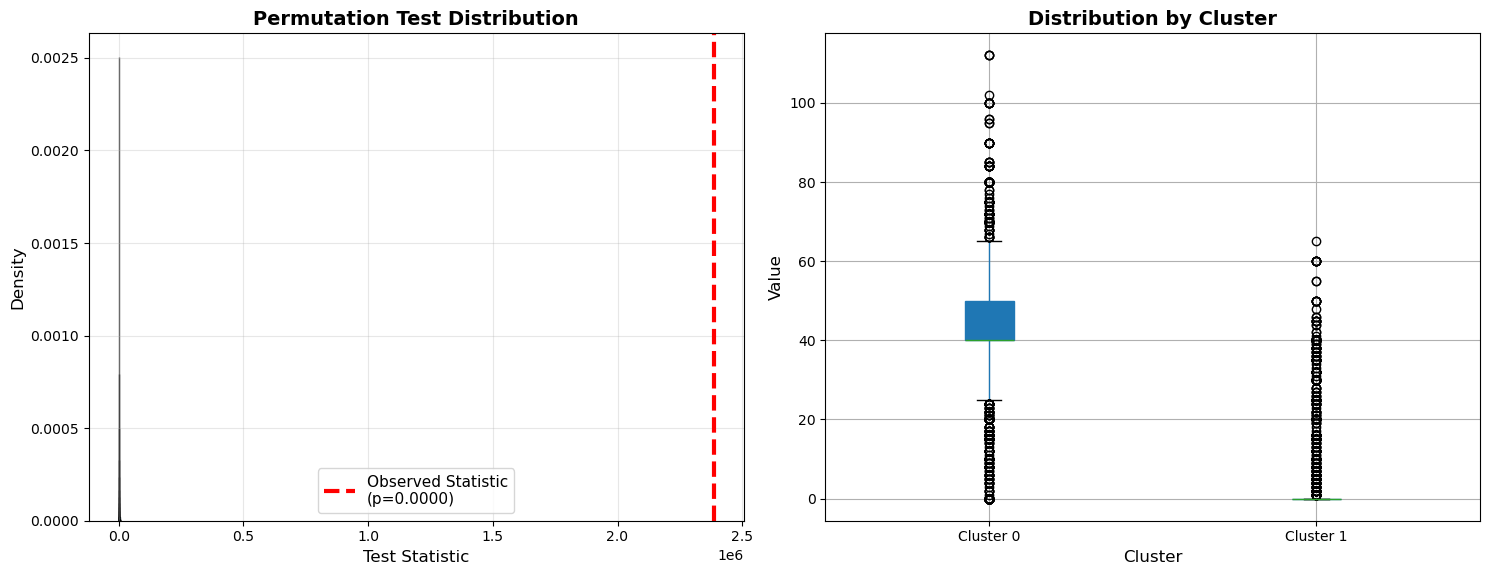


------------------------------------------------------------
Pairwise Cluster Comparisons (Permutation Tests)
------------------------------------------------------------
Cluster 0 vs 1: Mean Diff =    36.88, p = 0.0000 ***


In [15]:
# 6. PERMUTATION TESTS - NON-PARAMETRIC HYPOTHESIS TESTING
cluster_means = []
for i in range(optimal_k):
    cluster_subset = cluster_data_labeled[cluster_data_labeled['Cluster'] == i][temporal_cols[-1]]
    cluster_means.append(cluster_subset.mean())

grand_mean = cluster_data_labeled[temporal_cols[-1]].mean()
observed_stat = sum([len(cluster_data_labeled[cluster_data_labeled['Cluster'] == i]) * 
                      (cluster_means[i] - grand_mean)**2 
                      for i in range(optimal_k)])

print(f"\nObserved test statistic (between-cluster variance): {observed_stat:.2f}")

n_permutations = 10000
permuted_stats = []

np.random.seed(42)

for perm in range(n_permutations):
    if perm % 2000 == 0:
        print(f"  Progress: {perm}/{n_permutations}")
    
    permuted_labels = np.random.permutation(cluster_labels)
    
    perm_means = []
    for i in range(optimal_k):
        perm_subset = cluster_data_labeled[temporal_cols[-1]].values[permuted_labels == i]
        perm_means.append(np.mean(perm_subset))
    
    perm_stat = sum([np.sum(permuted_labels == i) * (perm_means[i] - grand_mean)**2 
                     for i in range(optimal_k)])
    permuted_stats.append(perm_stat)

permuted_stats = np.array(permuted_stats)

p_value_perm = np.mean(permuted_stats >= observed_stat)
print(f"  p-value: {p_value_perm:.4f}")

if p_value_perm < 0.05:
    print("Reject H₀: Clusters have significantly different wealth patterns (α=0.05)")
else:
    print("Fail to reject H₀: No significant difference between clusters (α=0.05)")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].hist(permuted_stats, bins=50, edgecolor='black', alpha=0.7, color='skyblue', density=True)
axes[0].axvline(observed_stat, color='red', linestyle='--', linewidth=3, 
               label=f'Observed Statistic\n(p={p_value_perm:.4f})')
axes[0].set_xlabel('Test Statistic', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Permutation Test Distribution', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

cluster_data_plot = []
cluster_labels_plot = []
for i in range(optimal_k):
    data = cluster_data_labeled[cluster_data_labeled['Cluster'] == i][temporal_cols[-1]].values
    cluster_data_plot.extend(data)
    cluster_labels_plot.extend([f'Cluster {i}'] * len(data))

df_boxplot = pd.DataFrame({'Value': cluster_data_plot, 'Cluster': cluster_labels_plot})
df_boxplot.boxplot(column='Value', by='Cluster', ax=axes[1], patch_artist=True)
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('Value', fontsize=12)
axes[1].set_title('Distribution by Cluster', fontsize=14, fontweight='bold')
plt.suptitle('') 

plt.tight_layout()
plt.savefig('permutation_test.png', dpi=300, bbox_inches='tight')
plt.show()

for i in range(optimal_k):
    for j in range(i+1, optimal_k):
        data_i = cluster_data_labeled[cluster_data_labeled['Cluster'] == i][temporal_cols[-1]].values
        data_j = cluster_data_labeled[cluster_data_labeled['Cluster'] == j][temporal_cols[-1]].values
        
        obs_diff = np.mean(data_i) - np.mean(data_j)
        
        combined = np.concatenate([data_i, data_j])
        n_i = len(data_i)
        perm_diffs = []
        
        for _ in range(1000):  
            perm_combined = np.random.permutation(combined)
            perm_diff = np.mean(perm_combined[:n_i]) - np.mean(perm_combined[n_i:])
            perm_diffs.append(perm_diff)
        
        p_val = np.mean(np.abs(perm_diffs) >= np.abs(obs_diff))
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"


Comparative Model Performance:
------------------------------------------------------------
Model                          R²           RMSE         Method
------------------------------------------------------------
ARIMA Time Series              0.0204       1386.11      Parametric
MLE Regression                 0.4379       15.66        Maximum Likelihood
Cluster Mean Baseline          0.6205       12.87        K-means Clustering
------------------------------------------------------------


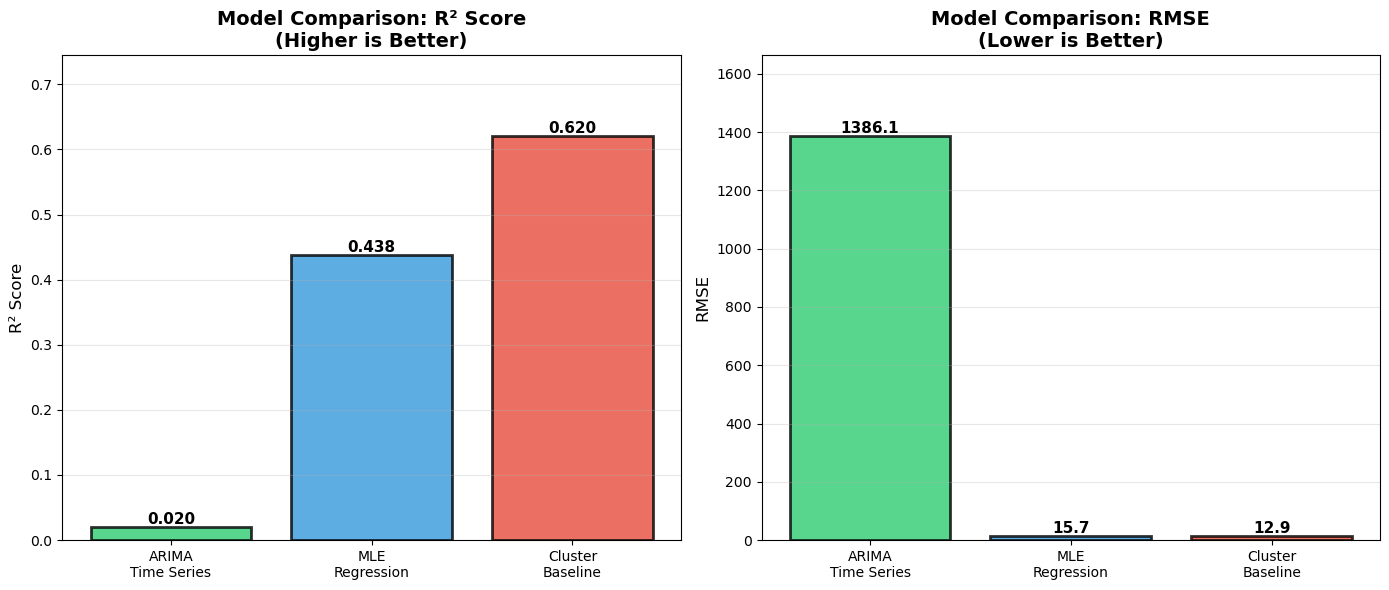

In [16]:
# 7. MODEL COMPARISON AND VALIDATION
print(f"{'ARIMA Time Series':<30} {r2:.4f}       {np.sqrt(mse):<12.2f} Parametric")
print(f"{'MLE Regression':<30} {r2_mle:.4f}       {np.sqrt(mse_mle):<12.2f} Maximum Likelihood")

y_pred_cluster = []
for idx, row in cluster_data_labeled.iterrows():
    cluster_id = row['Cluster']
    cluster_mean = cluster_data_labeled[cluster_data_labeled['Cluster'] == cluster_id][temporal_cols[-1]].mean()
    y_pred_cluster.append(cluster_mean)

y_actual_cluster = cluster_data_labeled[temporal_cols[-1]].values
mse_cluster = mean_squared_error(y_actual_cluster, y_pred_cluster)
r2_cluster = r2_score(y_actual_cluster, y_pred_cluster)
print(f"{'Cluster Mean Baseline':<30} {r2_cluster:.4f}       {np.sqrt(mse_cluster):<12.2f} K-means Clustering")

models = ['ARIMA\nTime Series', 'MLE\nRegression', 'Cluster\nBaseline']
r2_scores = [r2, r2_mle, r2_cluster]
rmse_scores = [np.sqrt(mse), np.sqrt(mse_mle), np.sqrt(mse_cluster)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#2ecc71', '#3498db', '#e74c3c']
bars1 = axes[0].bar(models, r2_scores, color=colors, edgecolor='black', linewidth=2, alpha=0.8)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('Model Comparison: R² Score\n(Higher is Better)', fontsize=14, fontweight='bold')
axes[0].set_ylim([0, max(r2_scores) * 1.2])
axes[0].grid(True, alpha=0.3, axis='y')

for bar, score in zip(bars1, r2_scores):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{score:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

bars2 = axes[1].bar(models, rmse_scores, color=colors, edgecolor='black', linewidth=2, alpha=0.8)
axes[1].set_ylabel('RMSE', fontsize=12)
axes[1].set_title('Model Comparison: RMSE\n(Lower is Better)', fontsize=14, fontweight='bold')
axes[1].set_ylim([0, max(rmse_scores) * 1.2])
axes[1].grid(True, alpha=0.3, axis='y')

for bar, score in zip(bars2, rmse_scores):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{score:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# 8. FINAL RESULTS AND CONCLUSIONS

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

<Figure size 1600x1000 with 0 Axes>

In [21]:
# 1. Cluster visualization 
ax1 = fig.add_subplot(gs[0, 0])
scatter = ax1.scatter(pca_features[:, 0], pca_features[:, 1], 
                     c=cluster_labels, cmap='viridis', s=30, alpha=0.6)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=9)
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=9)
ax1.set_title('A. Financial Behavior Clusters', fontsize=11, fontweight='bold')
plt.colorbar(scatter, ax=ax1, label='Cluster')

# 2. Time series 
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(range(len(ts_data)), ts_data, 'o-', linewidth=2, markersize=5)
ax2.plot(range(len(ts_data)), best_model.fittedvalues, 's--', 
        linewidth=2, markersize=4, alpha=0.7)
ax2.set_xlabel('Time Period', fontsize=9)
ax2.set_ylabel('Value', fontsize=9)
ax2.set_title(f'B. ARIMA{best_order} Time Series Model', fontsize=11, fontweight='bold')
ax2.legend(['Actual', 'Fitted'], fontsize=8)
ax2.grid(True, alpha=0.3)

# 3. MLE regression 
ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(X_mle_clean, y_mle_clean, alpha=0.4, s=30)
x_range = np.linspace(X_mle_clean.min(), X_mle_clean.max(), 100)
y_pred_line = beta_mle[0] + beta_mle[1] * x_range
ax3.plot(x_range, y_pred_line, 'r-', linewidth=2)
ax3.set_xlabel('Previous Period', fontsize=9)
ax3.set_ylabel('Current Period', fontsize=9)
ax3.set_title(f'C. MLE Regression (R²={r2_mle:.3f})', fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4. Cluster trajectories 
ax4 = fig.add_subplot(gs[1, 0])
for i in range(optimal_k):
    cluster_mean = cluster_data_labeled[cluster_data_labeled['Cluster'] == i][temporal_cols].mean()
    ax4.plot(range(len(temporal_cols)), cluster_mean, 
            marker='o', linewidth=2, markersize=5, label=f'Cluster {i}', alpha=0.8)
ax4.set_xlabel('Time Period', fontsize=9)
ax4.set_ylabel('Mean Value', fontsize=9)
ax4.set_title('D. Cluster Trajectories', fontsize=11, fontweight='bold')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# 5. Permutation test 
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(permuted_stats, bins=40, edgecolor='black', alpha=0.7, color='skyblue', density=True)
ax5.axvline(observed_stat, color='red', linestyle='--', linewidth=2)
ax5.set_xlabel('Test Statistic', fontsize=9)
ax5.set_ylabel('Density', fontsize=9)
ax5.set_title(f'E. Permutation Test (p={p_value_perm:.3f})', fontsize=11, fontweight='bold')
ax5.grid(True, alpha=0.3)

# 6. Model comparison R² 
ax6 = fig.add_subplot(gs[1, 2])
bars = ax6.bar(range(len(models)), r2_scores, color=colors, edgecolor='black', alpha=0.8)
ax6.set_xticks(range(len(models)))
ax6.set_xticklabels(['ARIMA', 'MLE', 'Cluster'], fontsize=9)
ax6.set_ylabel('R² Score', fontsize=9)
ax6.set_title('F. Model Performance (R²)', fontsize=11, fontweight='bold')
ax6.grid(True, alpha=0.3, axis='y')
for bar, score in zip(bars, r2_scores):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.3f}', ha='center', va='bottom', fontsize=8)

# 7. ACF plot 
ax7 = fig.add_subplot(gs[2, 0])
acf_vals = acf(ts_data.dropna(), nlags=min(len(ts_data)-1, 8))
ax7.stem(range(len(acf_vals)), acf_vals, basefmt=' ')
ax7.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax7.axhline(y=1.96/np.sqrt(len(ts_data)), color='red', linestyle='--', alpha=0.5)
ax7.axhline(y=-1.96/np.sqrt(len(ts_data)), color='red', linestyle='--', alpha=0.5)
ax7.set_xlabel('Lag', fontsize=9)
ax7.set_ylabel('ACF', fontsize=9)
ax7.set_title('G. Autocorrelation Function', fontsize=11, fontweight='bold')
ax7.grid(True, alpha=0.3)

# 8. Residual distribution
ax8 = fig.add_subplot(gs[2, 1])
residuals_mle = y_mle_clean - y_pred_mle
ax8.hist(residuals_mle, bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
ax8.axvline(0, color='red', linestyle='--', linewidth=2)
ax8.set_xlabel('Residuals', fontsize=9)
ax8.set_ylabel('Frequency', fontsize=9)
ax8.set_title('H. MLE Residual Distribution', fontsize=11, fontweight='bold')
ax8.grid(True, alpha=0.3)

# 9. Summary statistics table
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')
summary_text = f"""
SUMMARY STATISTICS

Sample Size: {len(df_clean)}
Time Periods: {len(temporal_cols)}
Clusters: {optimal_k}

Best Model: {models[np.argmax(r2_scores)].replace(chr(10), ' ')}
Max R²: {max(r2_scores):.4f}
Min RMSE: {min(rmse_scores):.2f}

Hypothesis Tests:
• Slope ≠ 0: {'Reject' if p_value_beta1<0.05 else 'Accept'} H₀
• Clusters differ: {'Reject' if p_value_perm<0.05 else 'Accept'} H₀

Significance: α = 0.05
"""
ax9.text(0.1, 0.5, summary_text, fontsize=10, verticalalignment='center',
        fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Comprehensive Analysis of Household Wealth Dynamics', 
            fontsize=16, fontweight='bold', y=0.995)
plt.savefig('final_summary.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>